In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/realtor-data.zip.csv')
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [9]:
df.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [11]:
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [12]:
df = df[['bed','bath','house_size','acre_lot','price']]
df.dropna()

,bed,bath,house_size,acre_lot,price
0,3.0,2.0,920.0,0.12,105000.0
1,4.0,2.0,1527.0,0.08,80000.0
2,2.0,1.0,748.0,0.15,67000.0
3,4.0,2.0,1800.0,0.10,145000.0
5,4.0,3.0,2520.0,0.46,179000.0
...,...,...,...,...,...
2226377,4.0,2.0,3600.0,0.33,359900.0
2226378,3.0,2.0,1616.0,0.10,350000.0
2226379,6.0,3.0,3200.0,0.50,440000.0
2226380,2.0,1.0,933.0,0.09,179900.0


In [13]:
df.head()

,bed,bath,house_size,acre_lot,price
0,3.0,2.0,920.0,0.12,105000.0
1,4.0,2.0,1527.0,0.08,80000.0
2,2.0,1.0,748.0,0.15,67000.0
3,4.0,2.0,1800.0,0.10,145000.0
4,6.0,2.0,NaN,0.05,65000.0


In [14]:
df.isnull().sum()

,0
bed,481317
bath,511771
house_size,568484
acre_lot,325589
price,1541


In [15]:
df = df[['bed','bath','house_size','acre_lot','price']]
df = df.dropna()

In [16]:
df.isnull().sum()

,0
bed,0
bath,0
house_size,0
acre_lot,0
price,0


In [17]:
from sklearn.linear_model import LinearRegression

X = df[['bed','bath','house_size','acre_lot']]
y = df['price']

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [18]:
import pandas as pd

new_house = pd.DataFrame({
    'bed': [3],
    'bath': [2],
    'house_size': [1800],
    'acre_lot': [0.2]
})
model.predict(new_house)

array([390515.93282694])

In [22]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X)
error = mean_absolute_error(y, preds)

print("Mean Absolut Error:", error)

Mean Absolut Error: 353978.62275969767


In [24]:
df.shape

(1360716, 5)

In [25]:
df_small = df.sample(20000, random_state=42)

In [26]:
X = df_small[['bed','bath','house_size','acre_lot']]
y = df_small['price']

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X,y)

RandomForestRegressor()

In [29]:
rf_model.predict(new_house)

array([416634.5])

In [31]:
from sklearn.metrics import mean_absolute_error

lr_preds = model.predict(X)
rf_preds = rf_model.predict(X)

print("Linear Regression Error: ", mean_absolute_error(y, lr_preds))
print("Random Forest Error:", mean_absolute_error(y, rf_preds))

Linear Regression Error:  349294.588812443
Random Forest Error: 125157.0061168529


In [34]:
def predict_price(bed, bath,size,acre):
    data = pd.DataFrame({
        'bed':[bed],
        'bath':[bath],
        'house_size': [size],
        'acre_lot':[acre]
    })
    prediction = rf_model.predict(data)[0]
    print("Predicted Price: ", round(prediction, 2))

In [35]:
predict_price(3,2,1800,0.2)

Predicted Price:  416634.5


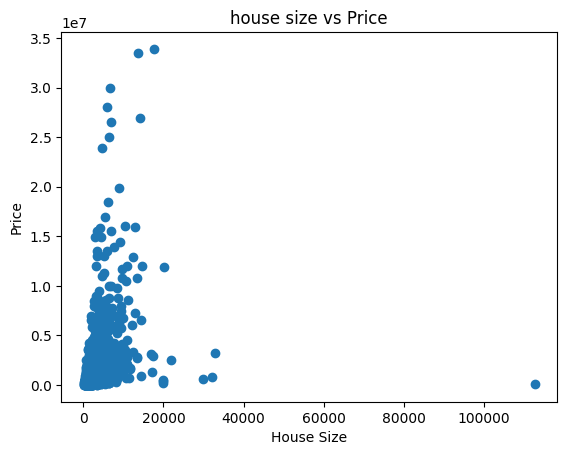

In [36]:
import matplotlib.pyplot as plt

plt.scatter(df_small['house_size'], df_small['price'])
plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("house size vs Price")
plt.show()

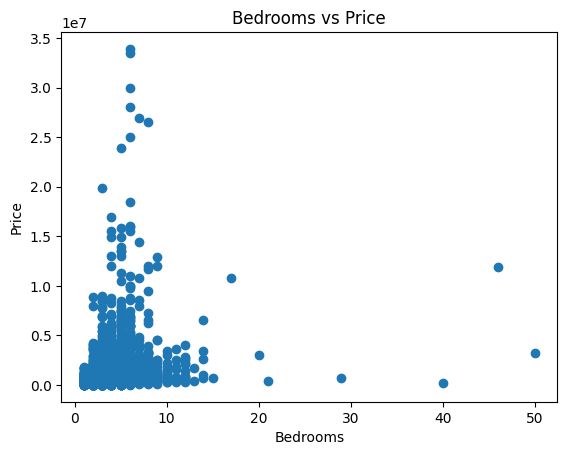

In [37]:
plt.scatter(df_small['bed'], df_small['price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")
plt.show()

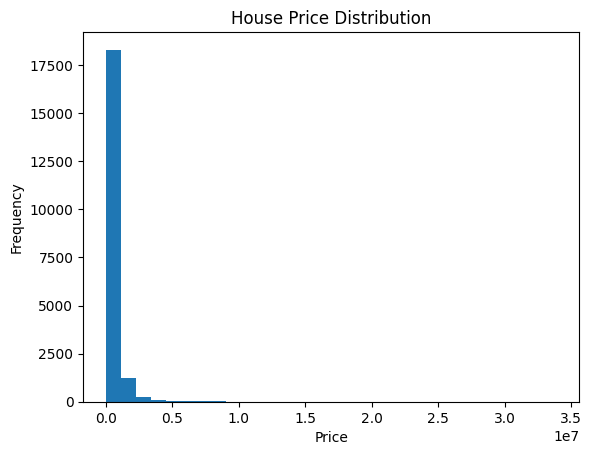

In [40]:
plt.hist(df_small['price'], bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("House Price Distribution")
plt.show()

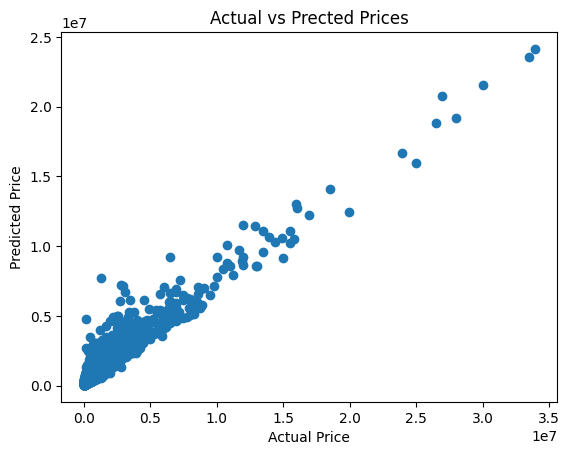

In [41]:
preds = rf_model.predict(X)

plt.scatter(y, preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Prected Prices")
plt.show()